# Бустинг (Boosting)

В этом ноутбуке разбираются:

1. Что такое бустинг и чем он принципиально отличается от бэггинга.
2. Модели бустинга в scikit-learn: `AdaBoostClassifier`,
   `GradientBoostingClassifier`/`Regressor`, `HistGradientBoosting...` —
   параметры, методы, поля.
3. Популярные внешние библиотеки бустинга: **XGBoost**, **LightGBM**,
   **CatBoost** — чем они отличаются друг от друга и от sklearn.
4. Основные преимущества и ограничения бустинга.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import modules.plots as mplts
import modules.style as style

from sklearn.datasets import make_classification, make_regression, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier, GradientBoostingRegressor,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)

sns.set_style("whitegrid")
%matplotlib inline

## 1. Что такое бустинг

Если бэггинг обучает много **независимых** моделей **параллельно** и
затем их усредняет, то бустинг устроен принципиально иначе:

* модели обучаются **последовательно**, одна за другой;
* каждая следующая модель **специально обучается исправлять ошибки**
  уже построенного на предыдущих шагах ансамбля — либо через
  перевзвешивание неправильно классифицированных объектов (AdaBoost),
  либо через обучение на остатке/антиградиенте функции потерь текущего
  ансамбля (Gradient Boosting);
* итоговый прогноз — не простое усреднение, а **взвешенная сумма**
  прогнозов всех моделей: $F_M(x) = \sum_{m=1}^{M} \nu\, h_m(x)$, где
  $\nu$ (`learning_rate`) — темп обучения, контролирующий вклад каждой
  новой модели.

Из-за этого устройства бустинг и бэггинг решают **разные** задачи:
бэггинг усредняет много *переобученных* (высокодисперсных) моделей,
снижая **разброс (variance)**; бустинг же обычно стартует с *очень
простых, слабых* моделей (например, "пеньков" — деревьев глубины 1,
каждый из которых сам по себе лишь немного лучше случайного угадывания)
и последовательно наращивает сложность ансамбля, снижая **смещение
(bias)** — систематическую ошибку, которую одна слабая модель никогда
не могла бы исправить в одиночку.

Ниже — та же концептуальная схема, что и в ноутбуке про бэггинг, но с
акцентом на правую половину: как последовательное добавление слабых
моделей, каждая из которых "донастраивается" под остаток, постепенно
приближает сумму к истинной зависимости.

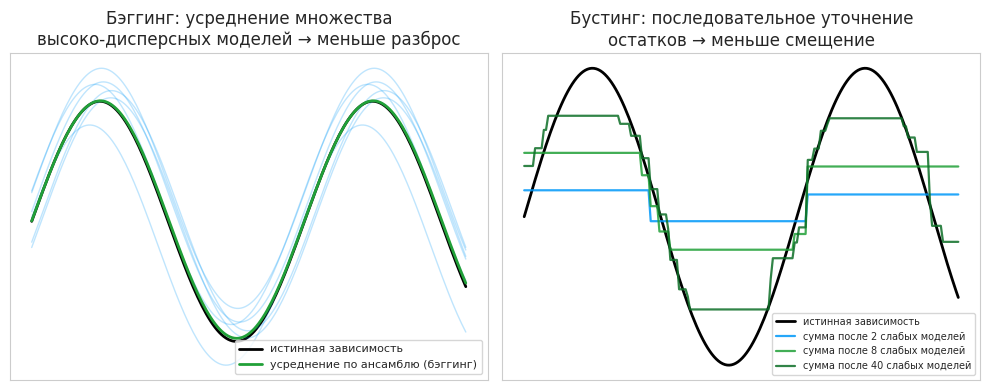

In [2]:
mplts.plot_bias_variance_schematic()
plt.show()

А вот та же идея не абстрактно, а на конкретном игрушечном
примере регрессии: на каждом шаге новое (очень простое — глубины 1)
дерево обучается предсказывать **остаток** ($y - $ текущая сумма
ансамбля), и его прогноз (с некоторым весом `learning_rate`)
добавляется к сумме. Видно, как с каждым шагом остаток (и его MSE)
уменьшается — именно так внутри устроен Gradient Boosting.

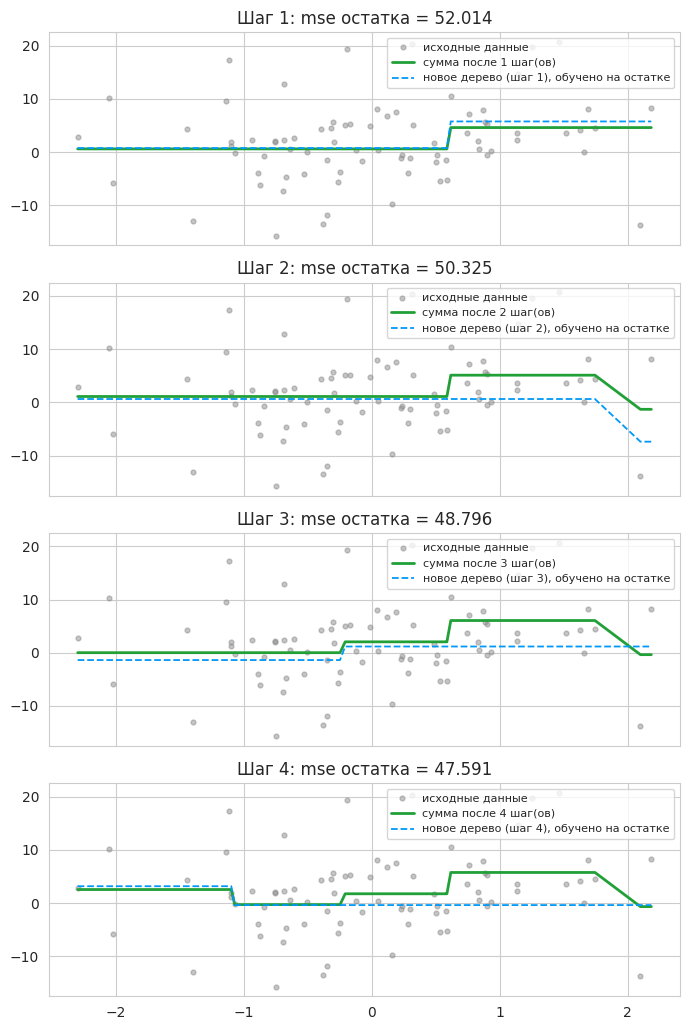

In [3]:
X_toy, y_toy = make_regression(n_samples=80, n_features=1, noise=8, random_state=1)
mplts.plot_boosting_sequential_fit(X_toy, y_toy, n_stages=4, max_depth=1, learning_rate=0.8)
plt.show()

### Формальная постановка: как именно "обучается" бустинг

Обучение бустинга — это пошаговая (жадная) минимизация суммарной
функции потерь на обучающей выборке. Формально, для функции потерь
$L(y, F(x))$ (её выбор зависит от задачи — регрессия, классификация
и т.д.) в идеале требовалось бы найти

$$
\hat F = \arg\min_{F} \sum_{i=1}^{n} L\big(y_i,\, F(x_i)\big)
$$

сразу среди всех возможных функций $F$ — но это безнадёжная задача.
Бустинг сужает поиск до **аддитивной модели**, строящейся **пошагово**
(forward stagewise additive modeling): начинаем с константы
$F_0(x) = \arg\min_{\gamma}\sum_i L(y_i, \gamma)$ (например, среднее
$y$ для квадратичной ошибки), а затем на каждом шаге $m = 1,\dots,M$

$$
h_m = \arg\min_{h} \sum_{i=1}^{n} L\big(y_i,\; F_{m-1}(x_i) + h(x_i)\big),
\qquad
F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x),
$$

то есть уже построенные модели **не трогаются** — ищется только одна
новая добавка $h_m$, сильнее всего уменьшающая ошибку уже построенного
ансамбля $F_{m-1}$ (отсюда "жадный", greedy алгоритм), а $\nu$ —
`learning_rate`.

**Проблема:** точно решить $\arg\min_h$ по произвольной функции $h$
(даже если $h$ — дерево) сложно. Идея **градиентного бустинга**
(Friedman, 2001) — заменить точное решение одним шагом **градиентного
спуска в пространстве функций**: новое дерево $h_m$ обучается не
напрямую минимизировать $L$, а **приближать антиградиент** функции
потерь по текущим прогнозам — т.н. псевдо-остатки:

$$
r_{im} = -\left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F(x_i) = F_{m-1}(x_i)},
\qquad
h_m \approx \arg\min_{h} \sum_{i=1}^{n} \big(r_{im} - h(x_i)\big)^2,
$$

где второе выражение — обычная задача регрессии (МНК): дерево $h_m$
подгоняется под таблицу $\{(x_i, r_{im})\}$. После этого можно ещё
подобрать оптимальный размер шага вдоль направления $h_m$:

$$
\gamma_m = \arg\min_{\gamma} \sum_{i=1}^{n} L\big(y_i,\, F_{m-1}(x_i) + \gamma\, h_m(x_i)\big).
$$

**Квадратичная функция потерь (регрессия, `loss="squared_error"`):**

$$
L(y, F) = \tfrac{1}{2}(y - F)^2
\quad\Longrightarrow\quad
r_{im} = -\frac{\partial L}{\partial F} = y_i - F_{m-1}(x_i).
$$

Антиградиент **в точности равен обычному остатку** — это и
демонстрировала иллюстрация выше: каждое новое дерево буквально
обучается на остатке $y - F_{m-1}(x)$.

**Логистическая (log-loss) функция потерь (бинарная классификация,
`loss="log_loss"` — именно она стоит по умолчанию в
`GradientBoostingClassifier`):**

$$
L(y, p) = -\big[y \log p + (1-y)\log(1-p)\big],
\qquad p = \sigma(F) = \frac{1}{1 + e^{-F}}
\quad\Longrightarrow\quad
r_{im} = y_i - p_{i,\,m-1},\;\; p_{i,\,m-1} = \sigma\big(F_{m-1}(x_i)\big).
$$

Здесь остаток — разница между истинной меткой ($0$ или $1$) и текущей
предсказанной вероятностью: та же идея, что и для регрессии, только в
пространстве логитов $F(x)$, а не самих меток $y$.

## 2. Модели бустинга в scikit-learn

### 2.1 `AdaBoostClassifier` (Adaptive Boosting)

Исторически первый популярный алгоритм бустинга. Идея: каждому объекту
обучающей выборки присваивается вес (изначально одинаковый для всех).
На каждой итерации:

1. Обучается слабая модель (по умолчанию — дерево глубины 1, "пень")
   с учётом текущих весов объектов.
2. Считается взвешенная ошибка `err_m` этой модели и её "вес голоса"
   в итоговом ансамбле $\alpha_m = \ln\frac{1 - err_m}{err_m}$ — чем
   точнее модель, тем больше её вклад.
3. Веса **неправильно классифицированных** объектов увеличиваются
   (домножаются на $e^{\alpha_m}$), чтобы следующая слабая модель
   уделила им больше внимания.

**Откуда берётся именно такая формула — и где здесь функция потерь.**
Сначала свяжем обозначения с общей схемой раздела 1. Там для уже
найденного (приближённо, через антиградиент) $h_m$ отдельно, вторым
шагом, подбирался оптимальный размер шага $\gamma_m$ вдоль направления
$h_m$. Для AdaBoost же, благодаря простому виду экспоненциальной
функции потерь и тому, что слабые модели $h$ принимают только значения
$\pm 1$, оказывается возможным решить **точно** (а не приближённо,
антиградиентом) — причём сразу для пары "направление и шаг"
одновременно, а не по отдельности, как в общем случае. Чтобы не путать
это с уже занятым обозначением $\gamma_m$ из общей схемы (там оно
находилось по-другому — приближённо, вторым шагом после $h_m$), для
точного совместного решения AdaBoost традиционно используют отдельное
обозначение $\beta_m$ — по сути это его аналог, просто для другого
способа получения.

Итак: AdaBoost — не какой-то отдельный от раздела 1 алгоритм, а частный
случай той же forward stagewise additive схемы для **экспоненциальной
функции потерь** $L(y, F) = e^{-yF(x)}$, $y \in \{-1, +1\}$. На шаге
$m$ нужно решить

$$
(\beta_m, h_m) = \arg\min_{\beta, h} \sum_{i=1}^{n} w_i^{(m)}\, e^{-\beta\, y_i h(x_i)},
\qquad w_i^{(m)} = e^{-y_i F_{m-1}(x_i)}.
$$

Так как $h(x_i) \in \{-1,+1\}$, слагаемое $y_i h(x_i)$ равно $+1$ для
верно классифицированных объектов и $-1$ для ошибочных, поэтому сумма
распадается на два слагаемых: $e^{-\beta}\!\!\sum_{\text{верно}} w_i^{(m)} + e^{\beta}\!\!\sum_{\text{ошибка}} w_i^{(m)}$. 
Приравняв производную по $\beta$ к нулю и обозначив взвешенную долю ошибок как $err_m$, получаем

$$
\beta_m = \tfrac{1}{2}\ln\frac{1-err_m}{err_m}.
$$

Поскольку для классификации имеет значение только *отношение* весов,
обновление $w_i^{(m+1)} = w_i^{(m)} e^{-\beta_m y_i h_m(x_i)}$
эквивалентно (после перенормировки) умножению весов **только ошибочных**
объектов на $e^{2\beta_m} = \frac{1-err_m}{err_m} = e^{\alpha_m}$ с
$\alpha_m = 2\beta_m = \ln\frac{1-err_m}{err_m}$ — это ровно та
формула и то правило обновления весов, что и в шагах 1–3 выше (то есть
$\alpha_m$ — это просто $2\beta_m$ в исторически принятой
нормировке AdaBoost). Иными словами: **AdaBoost
($\Leftrightarrow$ экспоненциальная функция потерь) — ровно то же самое
forward stagewise additive moделирование, что и в общей схеме раздела
1**, просто для конкретного (экспоненциального) $L$ решение
$\arg\min$ удаётся выписать аналитически, без приближения
антиградиентом.

**Параметры:** `estimator` (по умолчанию — пень), `n_estimators`,
`learning_rate` (масштабирует вклад $\alpha_m$ каждой модели).

**Методы/поля:** `.predict`, `.predict_proba`, `.staged_predict` /
`.staged_score` (прогноз/качество ансамбля после каждой добавленной
модели — удобно для построения кривых обучения, см. ниже),
`.estimator_weights_`, `.estimator_errors_`, `.feature_importances_`.

AdaBoost accuracy на тесте: 0.867


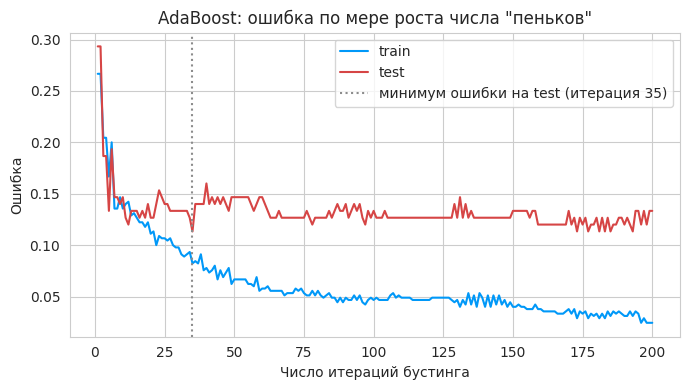

In [4]:
X_cls, y_cls = make_classification(n_samples=600, n_features=20, n_informative=8,
                                    n_redundant=4, flip_y=0.05, class_sep=0.8,
                                    random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, random_state=0)

ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                          n_estimators=200, learning_rate=1.0, random_state=0)
ada.fit(X_train, y_train)
print("AdaBoost accuracy на тесте:", round(ada.score(X_test, y_test), 3))

mplts.plot_staged_error_curve(ada, X_train, y_train, X_test, y_test,
                               title="AdaBoost: ошибка по мере роста числа \"пеньков\"")
plt.show()

### 2.2 `GradientBoostingClassifier` / `GradientBoostingRegressor`

Прямая реализация общей схемы из раздела 1: на каждом шаге новое дерево
обучается на псевдо-остатках $r_{im}$ (антиградиенте выбранного `loss`
по прогнозам текущего ансамбля $F_{m-1}$) — конкретные формулы $r_{im}$
для квадратичной и логистической функций потерь были выписаны выше.

**Основные параметры:**
* `loss` — функция потерь $L(y,F)$ (`"log_loss"` для классификации,
  `"squared_error"` и др. для регрессии — именно она определяет
  формулу антиградиента $r_{im}$ на каждом шаге);
* `n_estimators` — число последовательных деревьев $M$;
* `learning_rate` — темп обучения $\nu$ из формулы
  $F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x)$: чем он меньше, тем меньше
  вклад каждого отдельного дерева и тем больше деревьев обычно нужно
  (есть классический компромисс `learning_rate` ↔ `n_estimators`);
* `max_depth` / `max_leaf_nodes` — глубина/размер каждого дерева
  (в бустинге деревья обычно **гораздо мельче**, чем в случайном лесе
  — часто глубины 2–5, а не "до победного конца", так как здесь важна
  простота отдельной модели, а не её собственная точность);
* `subsample` — доля объектов, случайно отбираемая для обучения
  каждого дерева (< 1.0 — это т.н. **Stochastic Gradient Boosting**,
  добавляет немного "бэггинг-подобной" случайности для регуляризации);
* `validation_fraction`, `n_iter_no_change`, `tol` — встроенная ранняя
  остановка (early stopping) по отложенной части train, если качество
  перестаёт расти.

**Методы/поля:** `.staged_predict`/`.staged_decision_function` (как у
AdaBoost), `.feature_importances_`, `.train_score_` (loss на train по
итерациям).

Gradient Boosting accuracy на тесте: 0.887


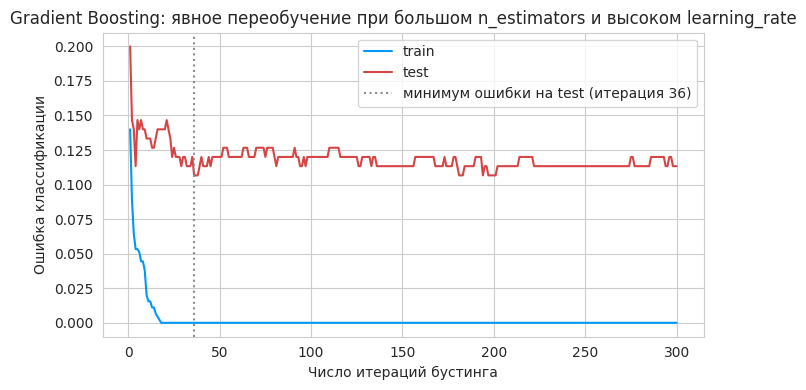

In [5]:
gb = GradientBoostingClassifier(n_estimators=300, learning_rate=0.5, max_depth=3,
                                 random_state=0)
gb.fit(X_train, y_train)
print("Gradient Boosting accuracy на тесте:", round(gb.score(X_test, y_test), 3))

def err(y_true, y_pred):
    return 1 - (y_true == y_pred).mean()

mplts.plot_staged_error_curve(gb, X_train, y_train, X_test, y_test, metric_func=err,
                               ylabel="Ошибка классификации",
                               title="Gradient Boosting: явное переобучение при "
                                     "большом n_estimators и высоком learning_rate")
plt.show()

Хорошо видно классическую картину переобучения: ошибка на train
монотонно падает почти до нуля, а ошибка на test после определённого
числа итераций перестаёт улучшаться и даже начинает расти — ансамбль
всё точнее подгоняется под шум конкретной обучающей выборки. Именно
поэтому для градиентного бустинга особенно важны небольшой
`learning_rate`, ограничение `n_estimators` (по кросс-валидации или
через `n_iter_no_change`) и небольшая глубина деревьев.

### 2.3 `HistGradientBoostingClassifier` / `Regressor`

Более современная и быстрая реализация градиентного бустинга в самом
scikit-learn, вдохновлённая LightGBM. Она отличается от "классического"
`GradientBoostingClassifier` из раздела 2.2 по двум независимым осям —
скорости построения дерева и способу вычисления значений в листьях.

**1. Гистограммное разбиение — почему это быстрее.** В обычном дереве
поиск лучшего порога разбиения по непрерывному признаку требует
отсортировать его значения и перебрать все возможные пороги между
соседними уникальными значениями — это $O(n\log n)$ на признак в
каждом узле. `HistGradientBoosting...` вместо этого **один раз**, перед
обучением, группирует значения каждого признака в гистограмму из
`max_bins` бинов (по умолчанию до 255) — то есть заменяет непрерывный
признак на его "огрублённую" версию с не более чем 255 возможными
значениями. Дальше поиск разбиения в любом узле — это перебор всего
`max_bins` границ бина (а не $n$ уникальных значений):

$$
\underbrace{O(n \log n)}_{\text{точный перебор порогов}}
\quad\longrightarrow\quad
\underbrace{O(n) + O(B)}_{\text{гистограммное разбиение}},
\qquad B = \texttt{max\_bins} \ll n,
$$

где $O(n)$ — однократное построение гистограммы (один проход по
данным), а $O(B)$ — уже сам перебор порогов внутри узла. Так как
$B \ll n$ и не растёт с размером датасета, это резко ускоряет
построение дерева на больших `n` и заодно снижает потребление памяти
(гистограмма занимает $O(B)$ памяти на признак вместо хранения всех
$n$ отсортированных значений).

**2. Значения в листьях — регуляризованный шаг Ньютона (как в
XGBoost/LightGBM), а не просто среднее по листу.** У
`HistGradientBoostingClassifier`/`Regressor` есть параметр
`l2_regularization` — его наличие само по себе говорит о том, что
модель использует **второй порядок** информации о функции потерь
(градиент **и** гессиан), в отличие от "классического"
`GradientBoostingClassifier`, где такого параметра нет и который лишь
приближает антиградиент обычной регрессией (раздел 2.2). Используя те
же обозначения $g_i, q_i$ (первая и вторая производные $L$ по $F$),
что и в формуле XGBoost из раздела 3 ниже, оптимальное значение в листе
$j$ (по объектам $R_j$, попавшим в этот лист) находится аналитически —
минимизируя квадратичную (по Тейлору) аппроксимацию потерь с
L2-штрафом $\frac{1}{2}\lambda w^2$ на величину самого значения листа:

$$
\sum_{i \in R_j} \Big[g_i\, w + \tfrac12 q_i\, w^2\Big] + \tfrac12 \lambda w^2
\;\xrightarrow[\ w\ ]{}\; \min
\quad\Longrightarrow\quad
w_j^{*} = -\,\frac{\displaystyle\sum_{i \in R_j} g_i}{\displaystyle\sum_{i \in R_j} q_i \;+\; \lambda},
$$

где $\lambda$ — как раз параметр `l2_regularization`: чем он больше,
тем сильнее "усредняются к нулю" (регуляризуются) значения в листьях —
дополнительная защита от переобучения по сравнению с обычным
усреднением остатков по листу.

Кроме этого, `HistGradientBoosting...` умеет из коробки работать с
пропусками (`NaN`) и категориальными признаками
(`categorical_features`), и имеет встроенный early stopping
(`early_stopping="auto"`, управляется `validation_fraction`,
`n_iter_no_change`, `scoring`).

Рекомендуется как более быстрая (и часто чуть более регуляризованная)
замена `GradientBoostingClassifier` на средних и больших датасетах.

In [6]:
hgb = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1,
                                      early_stopping=True, random_state=0)
hgb.fit(X_train, y_train)
print("HistGradientBoosting accuracy на тесте:", round(hgb.score(X_test, y_test), 3))
print("Число итераций до остановки (early stopping):", hgb.n_iter_)

HistGradientBoosting accuracy на тесте: 0.867
Число итераций до остановки (early stopping): 40


## 3. Внешние библиотеки бустинга: XGBoost, LightGBM, CatBoost

Помимо реализаций из scikit-learn, на практике для табличных данных
чаще всего используют одну из трёх специализированных библиотек — все
они реализуют градиентный бустинг из раздела 1, но с разными
оптимизациями:

* **XGBoost (eXtreme Gradient Boosting).** Одна из первых
  промышленных реализаций; вместо приближения только первой производной
  (антиградиентом, как в базовой схеме выше) использует **второй
  порядок** разложения функции потерь (метод Ньютона) и явную
  **регуляризацию сложности дерева** в целевой функции шага:

  $$
  \mathcal{L}^{(m)} = \sum_{i=1}^{n} L\big(y_i,\, F_{m-1}(x_i) + h_m(x_i)\big) + \Omega(h_m),
  \qquad
  \Omega(h) = \gamma T + \tfrac{1}{2}\lambda \sum_{j=1}^{T} w_j^2,
  $$

  где $T$ — число листьев дерева $h_m$, $w_j$ — значения (веса) в
  листьях, а $\gamma, \lambda$ — коэффициенты регуляризации (штраф за
  число листьев и за большие значения в листьях — это и есть
  "L1/L2-штраф на веса листьев", снижающий переобучение по сравнению с
  "ванильным" градиентным бустингом из раздела 1). Раскладывая
  $L(y_i, F_{m-1}(x_i)+h(x_i))$ в ряд Тейлора **второго порядка** вокруг
  $F_{m-1}(x_i)$ вместо первого:

  $$
  \mathcal{L}^{(m)} \approx \sum_{i=1}^{n}
  \Big[\,g_i\, h_m(x_i) + \tfrac{1}{2} q_i\, h_m(x_i)^2\,\Big] + \Omega(h_m),
  \qquad
  g_i = \frac{\partial L(y_i, F)}{\partial F}\Big|_{F_{m-1}(x_i)},\;\;
  q_i = \frac{\partial^2 L(y_i, F)}{\partial F^2}\Big|_{F_{m-1}(x_i)}
  $$

  (константный по $h_m$ член $L(y_i,F_{m-1}(x_i))$ опущен) — это
  позволяет для каждого варианта разбиения дерева **аналитически**
  посчитать оптимальные значения листьев и выигрыш от разбиения, а не
  только приближать остаток регрессией, как в базовой схеме. Кроме
  того, XGBoost эффективно работает с разреженными данными. Много лет
  была индустриальным стандартом.
* **LightGBM.** От Microsoft; ключевое отличие — деревья растут
  **по листьям (leaf-wise / best-first)**, а не по уровням
  (level-wise, как в GradientBoostingClassifier/XGBoost по умолчанию):
  на каждом шаге расщепляется тот лист, который сильнее всего уменьшит
  ошибку, а не "все листья текущего уровня". Это часто даёт более
  точные деревья при том же числе листьев, но и больше риск
  переобучения на маленьких данных (нужно тщательнее ограничивать
  глубину/число листьев). Использует гистограммное разбиение (как
  `HistGradientBoosting...`) и дополнительные приёмы (GOSS, EFB) для
  ускорения на очень больших датасетах.
* **CatBoost.** От Яндекса; специализируется на **категориальных
  признаках** — вместо ручного one-hot/label-кодирования умеет сама
  строить статистики по категориям (target statistics) в специальном
  "упорядоченном" (ordered) режиме, который предотвращает утечку
  целевой переменной. Также использует **симметричные (oblivious)
  деревья** (одно и то же условие разбиения на всех узлах одного
  уровня) и **ordered boosting** — модифицированную схему обучения,
  снижающую систематическое смещение прогнозов на обучающей выборке.
  Часто даёт хорошее качество "из коробки" с минимальной настройкой
  гиперпараметров.

Код ниже написан так, как он выглядел бы в окружении с установленными
библиотеками — если библиотека не установлена (как в этой песочнице
без доступа в интернет), ячейка не упадёт, а выведет соответствующее
сообщение.

In [7]:
try:
    from xgboost import XGBClassifier
    xgb_model = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=4,
                               reg_lambda=1.0, eval_metric="logloss", random_state=0)
    xgb_model.fit(X_train, y_train)
    print("XGBoost accuracy на тесте:", round(xgb_model.score(X_test, y_test), 3))
except ImportError:
    print("Библиотека xgboost не установлена в этом окружении "
          "(pip install xgboost). Код выше корректен и будет работать "
          "там, где библиотека доступна.")

Библиотека xgboost не установлена в этом окружении (pip install xgboost). Код выше корректен и будет работать там, где библиотека доступна.


In [8]:
try:
    from lightgbm import LGBMClassifier
    lgbm_model = LGBMClassifier(n_estimators=300, learning_rate=0.1, num_leaves=31,
                                 random_state=0, verbosity=-1)
    lgbm_model.fit(X_train, y_train)
    print("LightGBM accuracy на тесте:", round(lgbm_model.score(X_test, y_test), 3))
except ImportError:
    print("Библиотека lightgbm не установлена в этом окружении "
          "(pip install lightgbm). Код выше корректен и будет работать "
          "там, где библиотека доступна.")

Библиотека lightgbm не установлена в этом окружении (pip install lightgbm). Код выше корректен и будет работать там, где библиотека доступна.


In [9]:
try:
    from catboost import CatBoostClassifier
    cb_model = CatBoostClassifier(iterations=300, learning_rate=0.1, depth=6,
                                   random_state=0, verbose=False)
    cb_model.fit(X_train, y_train)
    print("CatBoost accuracy на тесте:", round(cb_model.score(X_test, y_test), 3))
except ImportError:
    print("Библиотека catboost не установлена в этом окружении "
          "(pip install catboost). Код выше корректен и будет работать "
          "там, где библиотека доступна. Главная сильная сторона CatBoost "
          "раскрывается на данных с категориальными признаками: там ей "
          "достаточно передать cat_features=[...] без ручного кодирования.")

Библиотека catboost не установлена в этом окружении (pip install catboost). Код выше корректен и будет работать там, где библиотека доступна. Главная сильная сторона CatBoost раскрывается на данных с категориальными признаками: там ей достаточно передать cat_features=[...] без ручного кодирования.


## 4. Преимущества и ограничения бустинга

### Преимущества

* **Снижает смещение (bias), а не только дисперсию** — может собрать
  сильный ансамбль даже из очень простых слабых моделей, с которыми
  бэггинг не справился бы (напомним: бэггинг не лечит bias).
* На данный момент **бустинг (особенно XGBoost/LightGBM/CatBoost) —
  один из самых сильных подходов на табличных/структурированных
  данных**, регулярно выигрывающий соревнования по machine learning
  на таких данных.
* Как и другие ансамбли на деревьях, даёт `feature_importances_` и
  устойчив к разным масштабам/типам признаков (не требует
  масштабирования, как линейные модели или kNN).
* Гибкость: можно оптимизировать практически любую дифференцируемую
  функцию потерь (регрессия, классификация, ранжирование, квантильная
  регрессия и т.д.) — достаточно подставить нужный `loss`/градиент.

### Ограничения

* **Принципиально последовательный процесс** — каждое следующее дерево
  зависит от результата предыдущих, поэтому, в отличие от бэггинга,
  обучение **нельзя тривиально распараллелить по `n_estimators`**
  (параллелится в основном только построение *одного* дерева).
  Это делает обучение медленнее при сравнимом числе моделей.
* **Больше гиперпараметров и больше риск переобучения**, если их не
  контролировать: `learning_rate`, `n_estimators`, глубина/число
  листьев дерева, `subsample` — все они взаимосвязаны, и, как было
  наглядно видно на графике в разделе 2, слишком большое `n_estimators`
  при слишком высоком `learning_rate` быстро приводит к переобучению.
  Бустинг требует более тщательной настройки и обязательной валидации
  (или ранней остановки), чем бэггинг/случайный лес, которые гораздо
  более устойчивы "из коробки" к выбору `n_estimators`.
* **Чувствительность к шуму и выбросам** — поскольку алгоритм
  последовательно фокусируется на объектах, на которых текущий
  ансамбль ошибается сильнее всего, шумные/аномальные примеры
  (например, ошибки разметки) могут получать непропорционально
  большое внимание (особенно заметно у AdaBoost из-за прямого
  перевзвешивания) и тянуть модель на переобучение под них.
* Требует больше практического опыта в настройке по сравнению со
  случайным лесом, у которого разумные значения по умолчанию почти
  всегда дают неплохой результат.

Ниже — итоговое сравнение: одиночное дерево, бэггинг (случайный лес),
AdaBoost, Gradient Boosting и HistGradientBoosting на одних и тех же
данных.

Одно дерево           : accuracy на тесте = 0.813
Random Forest         : accuracy на тесте = 0.900
AdaBoost              : accuracy на тесте = 0.867
Gradient Boosting     : accuracy на тесте = 0.873
HistGradientBoosting  : accuracy на тесте = 0.893


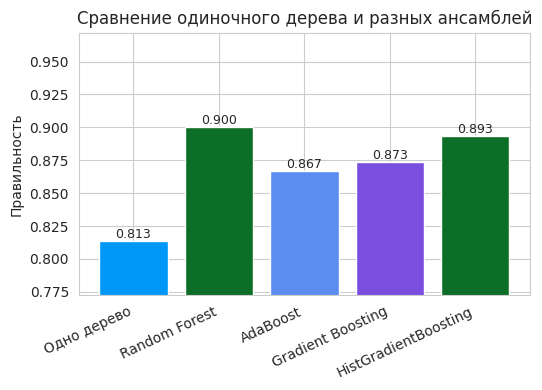

In [10]:
models_final = {
    "Одно дерево": DecisionTreeClassifier(random_state=0),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1),
    "AdaBoost": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                                    n_estimators=200, random_state=0),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, learning_rate=0.1,
                                                      max_depth=3, random_state=0),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=150, random_state=0),
}
final_scores = []
for name, model in models_final.items():
    model.fit(X_train, y_train)
    final_scores.append(model.score(X_test, y_test))
    print(f"{name:22s}: accuracy на тесте = {final_scores[-1]:.3f}")

mplts.plot_model_comparison_bars(list(models_final.keys()), final_scores,
                                  title="Сравнение одиночного дерева и разных ансамблей")
plt.show()

### Сводная таблица

| Модель | Тип рандомизации/обучения | Основной эффект | Когда использовать |
|---|---|---|---|
| `AdaBoostClassifier` | перевзвешивание объектов | снижение bias | простой baseline-бустинг, слабые базовые модели |
| `GradientBoostingClassifier`/`Regressor` | обучение на антиградиенте (остатке) | снижение bias, гибкий выбор loss | сильный baseline на табличных данных среднего размера |
| `HistGradientBoosting...` | то же + гистограммное биннинг признаков | то же, но быстрее на больших данных | средние/большие датасеты, нужна скорость |
| XGBoost | регуляризованный градиентный бустинг 2-го порядка | bias + контроль переобучения через регуляризацию | требователен к качеству — индустриальный стандарт |
| LightGBM | leaf-wise рост деревьев, гистограммы | bias, максимальная скорость на больших данных | очень большие датасеты, важна скорость обучения |
| CatBoost | ordered boosting + встроенная обработка категорий | bias + устойчивость к категориальным признакам | много категориальных признаков, нужна минимальная настройка |
